## Эффективное применение коллекций в пайнтон

### План занятия
1. Алгоритмическая сложность. 
- почему это важно
- почему важно эффективно использовать pandas, numpy и все коллекции python

2. Коллекции в python
- list
- dictionary
- set
- tuple

3. NumPy 
- основы, концепт, отличия от list, array

4. Pandas
- основы, адресация, оконные функции, агрегатные функции, фильтрация, группировка, агрегация

5. Порешаем алгоритмические задачки

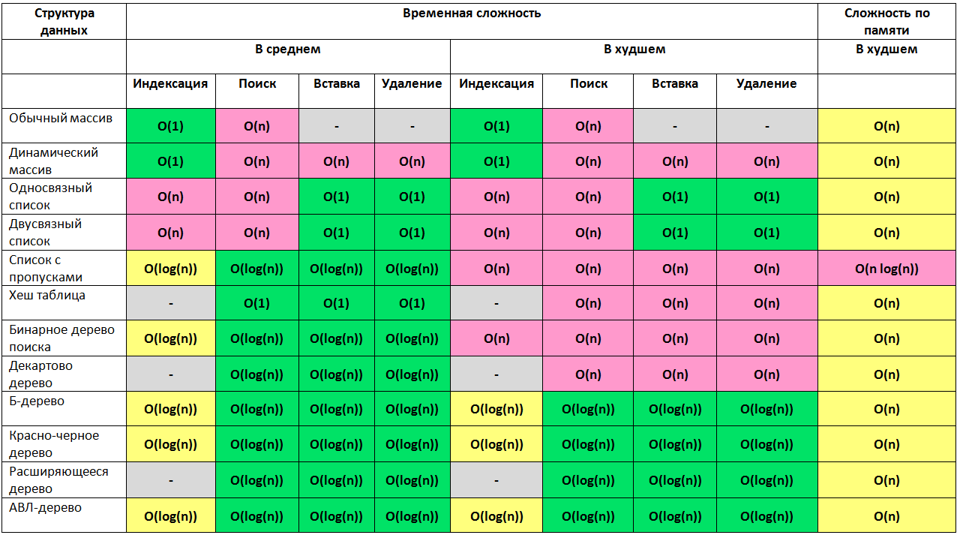

In [7]:
from IPython.display import Image
Image("sources/big_o.png")

### Основные коллекции

#### Пример list-set

In [13]:
import time

# 1. Неефективный поиск в списке (O(n))
lst = list(range(1_000_000))
start = time.time()
0 in lst
print("Поиск в списке:", time.time() - start, "сек.")

# 2. Эффективный поиск в множестве (O(1) среднее)
s = set(lst)
start = time.time()
999_999 in s
print("Поиск в set:", time.time() - start, "сек.")


Поиск в списке: 0.0 сек.
Поиск в set: 0.0 сек.


#### Пример list-set

In [14]:
# Считаем уникальные элементы списка вручную
lst = [1,2,3,1,2,3,4,5]
unique_manual = []
for x in lst:
    if x not in unique_manual:   # O(n) на каждую проверку
        unique_manual.append(x)
print("Уникальные вручную:", unique_manual)

# Гораздо эффективнее через set (O(1) на проверку)
unique_set = list(set(lst))
print("Уникальные через set:", unique_set)

Уникальные вручную: [1, 2, 3, 4, 5]
Уникальные через set: [1, 2, 3, 4, 5]


#### Пример list-deque
Вставляем элементы в список!!!

In [15]:
import time
from collections import deque

N = 20_000

# --- List ---
lst = []
start = time.time()
for i in range(N):
    lst.insert(0, i)   # вставка в начало
print("List вставка в начало:", time.time() - start, "сек.")

# --- Deque ---
dq = deque()
start = time.time()
for i in range(N):
    dq.appendleft(i)   # вставка в начало
print("Deque вставка в начало:", time.time() - start, "сек.")


List вставка в начало: 0.06944561004638672 сек.
Deque вставка в начало: 0.004045724868774414 сек.


### Heap

Пример: Хранение k самых маленьких элементов, которые были замечены на данный момент в большом потоке

Предположим, у вас есть большой поток (или большой список) чисел, и вы хотите всегда отслеживать k самых маленьких чисел, которые были замечены на данный момент (и отбрасывать остальные). Если делать это наивно, используя список и сортировку (или вставку в отсортированном порядке), это будет неэффективно. Куча гораздо эффективнее в таком случае.

In [16]:
import heapq
import random
import time

def top_k_with_heap(stream, k):
    heap = []
    for x in stream:
        if len(heap) < k:
            heapq.heappush(heap, -x)
        else:
            # If current x is smaller than the largest in the heap, replace
            if x < -heap[0]:
                # pop the largest (in inverted terms) and push the new one
                heapq.heapreplace(heap, -x)
    # Convert back to positive
    return sorted([-h for h in heap])

def top_k_with_list(stream, k):
    best = []
    for x in stream:
        best.append(x)
        best.sort()  # always keep sorted
        # optionally trim to k
        if len(best) > k:
            best.pop()  # drop the largest
    return best

def benchmark(n=200_000, k=100):
    stream = [random.randint(0, 1_000_000) for _ in range(n)]
    t0 = time.time()
    res1 = top_k_with_heap(stream, k)
    th = time.time() - t0

    t0 = time.time()
    res2 = top_k_with_list(stream, k)
    tl = time.time() - t0

    print("Heap version time: {:.3f} s".format(th))
    print("List (sort-every-insert) version time: {:.3f} s".format(tl))
    assert sorted(res1) == sorted(res2)
    return th, tl


th, tl = benchmark(n=200_000, k=100)
print("Speedup factor: {:.1f}×".format(tl / th))


Heap version time: 0.034 s
List (sort-every-insert) version time: 0.238 s
Speedup factor: 6.9×


### Бинарное дерево

In [17]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None

    def __str__(self):
        return str(self.data)

# корень
root = Node(1)

# Create child nodes
root.left = Node(2)
root.right = Node(3)

# Create grandchildren
root.left.left = Node(4)
root.left.right = Node(5)

print(root)
print(root.left)


1
2


In [ ]:
import heapq
import random
import time

def top_k_with_heap(stream, k):
    """Return the k smallest items from stream, using a max-heap trick (invert sign)."""
    # We'll maintain a heap of size <= k, storing negative values so the largest (inverted) is at root
    heap = []
    for x in stream:
        if len(heap) < k:
            heapq.heappush(heap, -x)
        else:
            # If current x is smaller than the largest in the heap, replace
            if x < -heap[0]:
                # pop the largest (in inverted terms) and push the new one
                heapq.heapreplace(heap, -x)
    # Convert back to positive
    return sorted([-h for h in heap])

def top_k_with_list(stream, k):
    """Return the k smallest items from stream, using a list + sort approach."""
    best = []
    for x in stream:
        best.append(x)
        best.sort()  # always keep sorted
        # optionally trim to k
        if len(best) > k:
            best.pop()  # drop the largest
    return best

def benchmark(n=200_000, k=100):
    stream = [random.randint(0, 1_000_000) for _ in range(n)]
    t0 = time.time()
    res1 = top_k_with_heap(stream, k)
    th = time.time() - t0

    t0 = time.time()
    res2 = top_k_with_list(stream, k)
    tl = time.time() - t0

    print("Heap version time: {:.3f} s".format(th))
    print("List (sort-every-insert) version time: {:.3f} s".format(tl))
    # compare correctness
    assert sorted(res1) == sorted(res2)
    return th, tl

if __name__ == "__main__":
    th, tl = benchmark(n=200_000, k=100)
    print("Speedup factor: {:.1f}×".format(tl / th))


#### Обход дерева

In [18]:
def inorder_traversal(node):
    if node:
        inorder_traversal(node.left)
        print(node, end=" ")
        inorder_traversal(node.right)
        
inorder_traversal(root)

4 2 5 1 3 

#### Красно-черное дерево
    
https://ds2-iiith.vlabs.ac.in/exp/red-black-tree/red-black-tree-oprations/simulation/redblack.html

### Numpy

#### 1. Создание массива

In [22]:
import numpy as np

a = np.array([1, 2, 3, 4, 5])      # из списка
print("Обычный массив:", a)

z = np.zeros((3, 3, 4))               # матрица 3х3 из нулей
print("Нули:\n", z)

o = np.ones((2, 4))                # матрица 2х4 из единиц
print("Единицы:\n", o)

r = np.arange(0, 20, 2).reshape((2, 5))            # последовательность [0, 2, 4, 6, 8]
print("Диапазон:", r)

lin = np.linspace(0, 1, 5)         # 5 равномерных чисел от 0 до 1
print("linspace:", lin)

rnd = np.random.rand(2, 3)         # случайная матрица 2х3
print("Случайные числа:\n", rnd)

Обычный массив: [1 2 3 4 5]
Нули:
 [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]]
Единицы:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]]
Диапазон: [[ 0  2  4  6  8]
 [10 12 14 16 18]]
linspace: [0.   0.25 0.5  0.75 1.  ]
Случайные числа:
 [[0.87149201 0.39305757 0.85622415]
 [0.47748845 0.19159962 0.0368142 ]]


In [24]:
z[0, :, :]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

#### 2. Векторные операции

In [26]:
a = np.array([1, 2, 3, 4])

print("a * 2 =", a * 2)         # умножение каждого элемента
print("a + 10 =", a + 10)       # сложение
print("a ** 2 =", a ** 2)       # возведение в квадрат
print("sum =", a.sum())
print("mean =", a.mean())

a * 2 = [2 4 6 8]
a + 10 = [11 12 13 14]
a ** 2 = [ 1  4  9 16]
sum = 10
mean = 2.5


#### 3. Индексация и срезы

In [27]:
b = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

print("Весь массив:\n", b)
print("Один элемент b[1,2] =", b[1, 2])   # 60
print("Один ряд b[0] =", b[0])           # первая строка
print("Срез b[:,1] =", b[:, 1])          # второй столбец


Весь массив:
 [[10 20 30]
 [40 50 60]
 [70 80 90]]
Один элемент b[1,2] = 60
Один ряд b[0] = [10 20 30]
Срез b[:,1] = [20 50 80]


#### 4. Булева индексация (фильтрация)

In [28]:
a = np.array([10, 15, 20, 25, 30])
mask = a > 20
print("Маска:", mask)
print("Фильтрованные значения:", a[mask])


Маска: [False False False  True  True]
Фильтрованные значения: [25 30]


#### 5. Операции с матрицами

In [ ]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A + B =\n", A + B)
print("A * B (поэлементно)=\n", A * B)
print("A @ B (матричное умножение)=\n", A @ B)   # или np.dot(A, B)
print("Транспонирование A.T =\n", A.T)


#### 6. Статистика и агрегаты

In [29]:
data = np.random.randint(0, 100, size=10)
print("Данные:", data)
print("min:", data.min())
print("max:", data.max())
print("mean:", data.mean())
print("std:", data.std())   # стандартное отклонение


Данные: [44 87 17 19 41 94 72 26 64 21]
min: 17
max: 94
mean: 48.5
std: 27.470893687683333


#### 7. Сравнение NumPy и list по скорости

In [30]:
import time

N = 1_000_000
lst = list(range(N))
arr = np.arange(N)

# list
start = time.time()
sum([x**2 for x in lst])
print("list:", time.time() - start, "сек.")

# numpy
start = time.time()
sum(arr**2)
print("numpy:", time.time() - start, "сек.")


list: 0.23617887496948242 сек.
numpy: 0.003999948501586914 сек.


### Pandas 

#### База

In [32]:
data = {
    "Имя": ["Аня", "Борис", "Вика", "Аня", "Борис"],
    "Месяц": ["Янв", "Янв", "Фев", "Фев", "Фев"],
    "Продажи": [100, 200, 150, 50, 300]
}

df = pd.DataFrame(data)
print(df)

     Имя Месяц  Продажи
0    Аня   Янв      100
1  Борис   Янв      200
2   Вика   Фев      150
3    Аня   Фев       50
4  Борис   Фев      300


In [38]:
list(df['Месяц'].unique())

['Янв', 'Фев']

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Имя      5 non-null      object
 1   Месяц    5 non-null      object
 2   Продажи  5 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes


In [47]:
mask = df["Продажи"] >= 100
mask

0     True
1     True
2     True
3    False
4     True
Name: Продажи, dtype: bool

#### Фильтрация и выборки

In [48]:
print(df[mask & (df["Имя"] == "Аня")])

   Имя Месяц  Продажи
0  Аня   Янв      100


#### Группировка и агрегация

In [50]:
# Общие продажи по каждому человеку
print(df.groupby("Имя")["Продажи"].sum())
print()
# Продажи по человеку и месяцу
print(df.groupby(["Имя", "Месяц"])["Продажи"].agg(["sum", "mean"]))


Имя
Аня      150
Борис    500
Вика     150
Name: Продажи, dtype: int64

             sum   mean
Имя   Месяц            
Аня   Фев     50   50.0
      Янв    100  100.0
Борис Фев    300  300.0
      Янв    200  200.0
Вика  Фев    150  150.0


#### MultiIndex (иерархический индекс)

In [51]:
# Делаем многоуровневый индекс
df_multi = df.set_index(["Имя", "Месяц"]).sort_index()
print(df_multi)
print('-' * 20)
# Доступ по индексу
print(df_multi.loc["Аня"])         # все месяцы для Ани
print('-' * 20)
print(df_multi.loc[("Борис", "Фев")])  # конкретный уровень


             Продажи
Имя   Месяц         
Аня   Фев         50
      Янв        100
Борис Фев        300
      Янв        200
Вика  Фев        150
--------------------
       Продажи
Месяц         
Фев         50
Янв        100
--------------------
Продажи    300
Name: (Борис, Фев), dtype: int64


#### Срезы по MultiIndex

In [53]:
# Используем pd.IndexSlice для удобных срезов
idx = pd.IndexSlice

ind_cond = idx[:, "Фев"]
print(df_multi.loc[ind_cond, :])   # все люди в феврале
print('-'*20)
print(df_multi.loc[idx["Аня":"Вика", :], :])   # диапазон по именам

             Продажи
Имя   Месяц         
Аня   Фев         50
Борис Фев        300
Вика  Фев        150
--------------------
             Продажи
Имя   Месяц         
Аня   Фев         50
      Янв        100
Борис Фев        300
      Янв        200
Вика  Фев        150


#### Оконные функции

In [54]:
df["СкользящееСреднее"] = df["Продажи"].rolling(2).mean()
print(df)
print('-'*20)
df["КумулятивнаяСумма"] = df["Продажи"].cumsum()
print(df)


     Имя Месяц  Продажи  СкользящееСреднее
0    Аня   Янв      100                NaN
1  Борис   Янв      200              150.0
2   Вика   Фев      150              175.0
3    Аня   Фев       50              100.0
4  Борис   Фев      300              175.0
--------------------
     Имя Месяц  Продажи  СкользящееСреднее  КумулятивнаяСумма
0    Аня   Янв      100                NaN                100
1  Борис   Янв      200              150.0                300
2   Вика   Фев      150              175.0                450
3    Аня   Фев       50              100.0                500
4  Борис   Фев      300              175.0                800


#### Срезы по датам (Time Series)

In [55]:
dates = pd.date_range("2023-01-01", periods=6, freq="M")
ts = pd.Series(np.random.randint(10, 100, size=6), index=dates)
print(ts)
print('-' * 20)
print(ts["2023-03":"2023-05"])  # срез по датам


2023-01-31    80
2023-02-28    79
2023-03-31    82
2023-04-30    78
2023-05-31    96
2023-06-30    82
Freq: ME, dtype: int32
--------------------
2023-03-31    82
2023-04-30    78
2023-05-31    96
Freq: ME, dtype: int32


C:\Users\semen\AppData\Local\Temp\ipykernel_21560\379567671.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range("2023-01-01", periods=6, freq="M")


#### Merge

In [59]:
# Первый DataFrame
df1 = pd.DataFrame({
    'id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David']
})

# Второй DataFrame
df2 = pd.DataFrame({
    'id': [2, 4, 5],
    'age': [30, 40, 50]
})

# Слияние по столбцу id (inner join по умолчанию)
merged_inner = df1.merge(df2, on='id', how='right')
print("Inner merge:")
print(merged_inner)



Inner merge:
   id   name  age
0   2    Bob   30
1   4  David   40
2   5    NaN   50


In [60]:
# Левое слияние (все из df1, если есть совпадение — берем из df2, иначе NaN)
merged_left = df1.merge(df2, on='id', how='left')
print("\nLeft merge:")
print(merged_left)



Left merge:
   id     name   age
0   1    Alice   NaN
1   2      Bob  30.0
2   3  Charlie   NaN
3   4    David  40.0


In [61]:
# Полное внешнее слияние (outer) — все из обоих, где нет совпадения — NaN
merged_outer = df1.merge(df2, on='id', how='outer')
print("\nOuter merge:")
print(merged_outer)


Outer merge:
   id     name   age
0   1    Alice   NaN
1   2      Bob  30.0
2   3  Charlie   NaN
3   4    David  40.0
4   5      NaN  50.0


In [66]:
import pandas as pd
import time
import numpy as np

np.random.seed(42)
n = 1000000
df1 = pd.DataFrame({
    'key': range(n),
    'value1': np.random.rand(n)
})
df2 = pd.DataFrame({
    'key': range(n),
    'value2': np.random.rand(n)
})

df1 = df1.sample(frac=1, random_state=42)
df2 = df2.sample(frac=1, random_state=42)

df1_indexed = df1.set_index('key')
df2_indexed = df2.set_index('key')

def measure_time(func, desc):
    start = time.time()
    result = func()
    end = time.time()
    print(f"{desc}: {end - start:.4f} seconds")
    return result

def join_without_index():
    return pd.merge(df1, df2, on='key', how='inner')

def join_with_index():
    return df1_indexed.join(df2_indexed, how='inner')

# Run and time both operations
print(f"Dataset size: {n} rows")
measure_time(join_without_index, "Join без индексов")
measure_time(join_with_index, "Join с индексами")
print()


Dataset size: 1000000 rows
Join без индексов: 0.3191 seconds
Join с индексами: 0.1395 seconds



### Itertools
https://docs.python.org/3/library/itertools.html#itertools.combinations


In [67]:
import itertools

for i in itertools.permutations([1, 2, 3]):
    print(i)

(1, 2, 3)
(1, 3, 2)
(2, 1, 3)
(2, 3, 1)
(3, 1, 2)
(3, 2, 1)


In [68]:
for i in itertools.product([1, 2, 3], [4, 5, 6]):
    print(i)

(1, 4)
(1, 5)
(1, 6)
(2, 4)
(2, 5)
(2, 6)
(3, 4)
(3, 5)
(3, 6)


In [73]:
for i in itertools.combinations('ABC', 2):
    print(i)

('A', 'B')
('A', 'C')
('B', 'C')


In [71]:
for i in  itertools.combinations_with_replacement('ABC', 2):
    print(i)

('A', 'A')
('A', 'B')
('A', 'C')
('B', 'B')
('B', 'C')
('C', 'C')


In [ ]:
https://leetcode.com/problems/merge-sorted-array/description/?envType=problem-list-v2&envId=sorting
https://leetcode.com/problems/remove-duplicates-from-sorted-array/description/
https://leetcode.com/problems/majority-element/description/?envType=problem-list-v2&envId=hash-table


In [74]:
nums = [2,2,1,1,1,2,2]

from collection import Counter

def met(nums):
    counter = Counter(nums)
    return max(counter)

met(nums)

ModuleNotFoundError: No module named 'collection'